In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [15]:
#Load the full training dataset

transform = transforms.ToTensor()

full_train_dataset = datasets.MNIST(
    root="data/raw",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data/raw",
    train=False,
    download=True,
    transform=transform
)


In [16]:
#Split it

train_size = 50000
val_size = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [17]:
#Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)


In [18]:
# Define your ANN

class MNIST_ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


In [19]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward propagation
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        total_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


In [20]:
#Create validation function

model.eval()


NameError: name 'model' is not defined

In [ ]:
torch.no_grad()


In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


In [ ]:
#Train the model

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cpu


In [ ]:
#Create the model
model = MNIST_ANN().to(device)


In [ ]:
#Loss
criterion = nn.CrossEntropyLoss()


In [27]:
#Optimizer:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


In [ ]:
# Set epochs

epochs = 10


In [30]:
#Create a history dictionary
history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}


In [31]:
#Training + validation loop
for epoch in range(epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(
        train_accuracy
    )

    history["val_accuracy"].append(
        val_accuracy
    )

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )


Epoch [1/10] Train Loss: 0.3674 | Val Loss: 0.2276 | Train Acc: 0.9018 | Val Acc: 0.9315
Epoch [2/10] Train Loss: 0.1767 | Val Loss: 0.1535 | Train Acc: 0.9487 | Val Acc: 0.9546
Epoch [3/10] Train Loss: 0.1266 | Val Loss: 0.1272 | Train Acc: 0.9632 | Val Acc: 0.9609
Epoch [4/10] Train Loss: 0.0968 | Val Loss: 0.1074 | Train Acc: 0.9717 | Val Acc: 0.9676
Epoch [5/10] Train Loss: 0.0767 | Val Loss: 0.0993 | Train Acc: 0.9779 | Val Acc: 0.9705
Epoch [6/10] Train Loss: 0.0620 | Val Loss: 0.0982 | Train Acc: 0.9813 | Val Acc: 0.9691
Epoch [7/10] Train Loss: 0.0504 | Val Loss: 0.0863 | Train Acc: 0.9850 | Val Acc: 0.9754
Epoch [8/10] Train Loss: 0.0412 | Val Loss: 0.0843 | Train Acc: 0.9880 | Val Acc: 0.9743
Epoch [9/10] Train Loss: 0.0336 | Val Loss: 0.0851 | Train Acc: 0.9902 | Val Acc: 0.9746
Epoch [10/10] Train Loss: 0.0288 | Val Loss: 0.0844 | Train Acc: 0.9920 | Val Acc: 0.9757


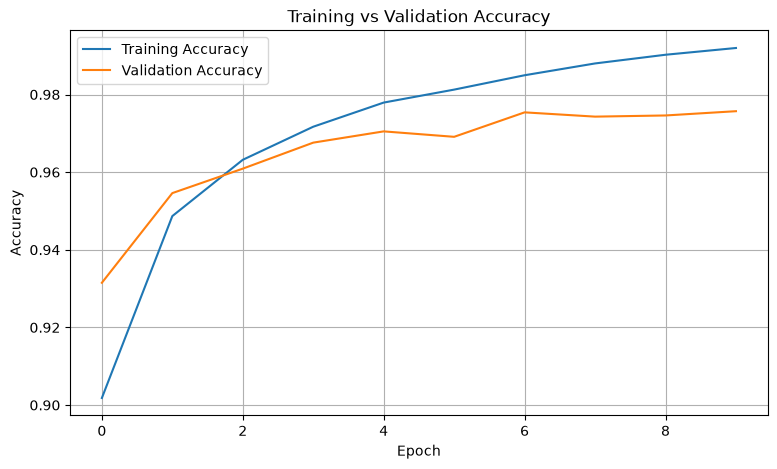

In [34]:
plt.figure(figsize=(9, 5))

plt.plot(
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()


In [35]:
best_epoch = torch.tensor(
    history["val_accuracy"]
).argmax().item()

best_accuracy = history["val_accuracy"][
    best_epoch
]

print("Best epoch:", best_epoch + 1)
print("Best validation accuracy:", best_accuracy)


Best epoch: 10
Best validation accuracy: 0.9757
